<a href="https://colab.research.google.com/github/shanmukhas928/samsung/blob/main/Copy_of_ProjectShanmukha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#NAME:SHANMUKHA S
#USN:1AJ22CS141
#COLLEGE:CAMBRIDGE INSTITUTE OF TECHNOLOGY NORTH CAMPUS
#E-mail:shanmukhas928@gmail.com
#PROJECT:WIND POWER PREDICTION

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

#Data Importing And Data Information

In [ ]:
df=pd.read_csv('wind_power.csv')

In [ ]:
df.shape

(1000, 14)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   wind_speed_ms               961 non-null    float64
 1   blade_length_m              939 non-null    float64
 2   turbine_age_years           953 non-null    float64
 3   hub_height_m                949 non-null    float64
 4   turbine_type                953 non-null    object 
 5   rated_power_kw              949 non-null    float64
 6   cut_in_speed_ms             954 non-null    float64
 7   cut_out_speed_ms            949 non-null    float64
 8   air_density_kgm3            956 non-null    float64
 9   turbulence_intensity        948 non-null    float64
 10  maintenance_status          947 non-null    object 
 11  terrain_type                946 non-null    object 
 12  wind_direction_variability  952 non-null    object 
 13  power_output_kw             960 no

these are data of above the variable

In [ ]:
df.head()

,wind_speed_ms,blade_length_m,turbine_age_years,hub_height_m,turbine_type,rated_power_kw,cut_in_speed_ms,cut_out_speed_ms,air_density_kgm3,turbulence_intensity,maintenance_status,terrain_type,wind_direction_variability,power_output_kw
0,5.104369,47.091836,8.830999,70.339044,Horizontal Axis,NaN,3.162759,23.060822,1.219210,0.195353,Good,Hilly,High,2792.360710
1,17.666834,44.622260,0.501787,96.460496,Vertical Axis,3000.0,3.861805,21.494328,1.231188,0.246581,Poor,Hilly,NaN,6175.704023
2,12.157650,31.458768,14.175217,100.280458,Vertical Axis,1500.0,2.872925,22.152184,1.266904,0.170637,Poor,Offshore,High,7745.335181
3,8.910482,48.563840,6.885122,108.069957,Horizontal Axis,3000.0,3.701177,20.855190,1.229892,0.143366,Fair,Hilly,High,1358.078129
4,19.360413,40.550983,16.540931,120.246598,Vertical Axis,2000.0,3.444390,NaN,1.131276,0.164824,Excellent,Hilly,Medium,7432.914789


In [ ]:
df['wind_speed_ms'].isna().sum()

np.int64(39)

In [ ]:
df['blade_length_m'].isna().sum()

np.int64(61)

In [ ]:
df['turbine_age_years'].isna().sum()

np.int64(47)

In [ ]:
df['power_output_kw'].isna().sum()

np.int64(40)

In [ ]:
df.isnull().sum()

,0
wind_speed_ms,39
blade_length_m,61
turbine_age_years,47
hub_height_m,51
turbine_type,47
rated_power_kw,51
cut_in_speed_ms,46
cut_out_speed_ms,51
air_density_kgm3,44
turbulence_intensity,52


<Axes: ylabel='None'>

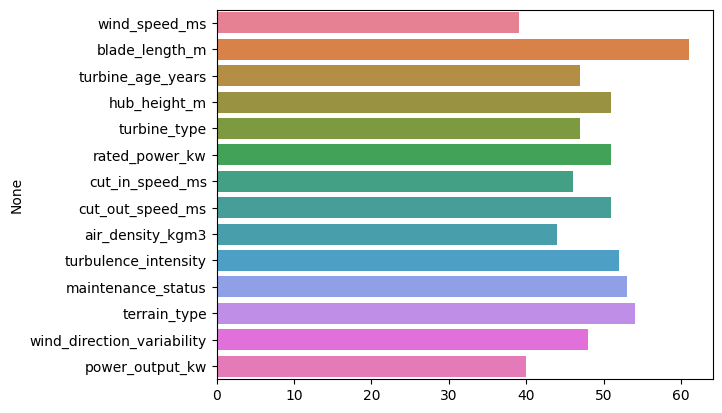

In [ ]:
sns.barplot(x=df.isnull().sum().values,y=df.isnull().sum().index,hue=df.isnull().sum().index)

#Data Preprocessing/Cleaning


In [ ]:
df.columns

Index(['wind_speed_ms', 'blade_length_m', 'turbine_age_years', 'hub_height_m',
       'turbine_type', 'rated_power_kw', 'cut_in_speed_ms', 'cut_out_speed_ms',
       'air_density_kgm3', 'turbulence_intensity', 'maintenance_status',
       'terrain_type', 'wind_direction_variability', 'power_output_kw'],
      dtype='object')

In [ ]:
avg_wind_speed_ms=df['wind_speed_ms'].mean()
avg_wind_speed_ms

np.float64(13.856393410893842)

In [ ]:
df['wind_speed_ms']=df['wind_speed_ms'].fillna(avg_wind_speed_ms)
df['wind_speed_ms'].isna().sum()

np.int64(0)

In [ ]:
print(df['wind_speed_ms'].isna().sum())

0


In [ ]:
avr_blade_length_m=df['blade_length_m'].mean()
avr_blade_length_m

np.float64(50.09595648419804)

In [ ]:
df['blade_length_m']=df['blade_length_m'].fillna(avr_blade_length_m)
df['blade_length_m'].isna().sum()

np.int64(0)

In [ ]:
avr_turbine_age_years=df['turbine_age_years'].mean()
avr_turbine_age_years

np.float64(9.564361518076087)

In [ ]:
df['turbine_age_years']=df['turbine_age_years'].fillna(avr_turbine_age_years)
df['turbine_age_years'].isna().sum()

np.int64(0)

In [ ]:
avr_hub_height_m=df['hub_height_m'].mode()[0]
avr_hub_height_m

np.float64(60.036741988724096)

In [ ]:
num_cols = df.select_dtypes(include=['number']).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].mean())


obj_cols = df.select_dtypes(include=['object']).columns
for col in obj_cols:
    df[col].fillna(df[col].mode()[0], inplace=True)


print(df.isnull().sum())

wind_speed_ms                 0
blade_length_m                0
turbine_age_years             0
hub_height_m                  0
turbine_type                  0
rated_power_kw                0
cut_in_speed_ms               0
cut_out_speed_ms              0
air_density_kgm3              0
turbulence_intensity          0
maintenance_status            0
terrain_type                  0
wind_direction_variability    0
power_output_kw               0
dtype: int64


# GRAPHS

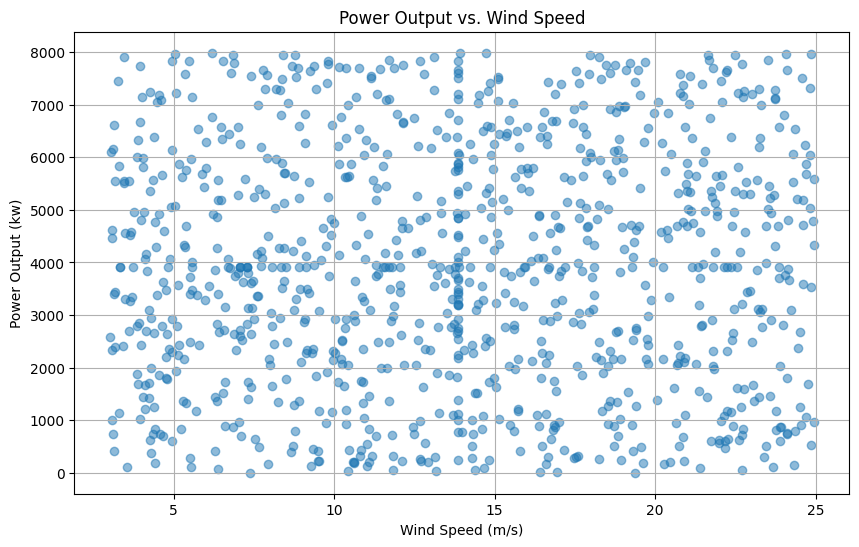

In [ ]:
plt.figure(figsize=(10, 6))
plt.scatter(df['wind_speed_ms'], df['power_output_kw'], alpha=0.5)
plt.title('Power Output vs. Wind Speed')
plt.xlabel('Wind Speed (m/s)')
plt.ylabel('Power Output (kw)')
plt.grid(True)
plt.show()

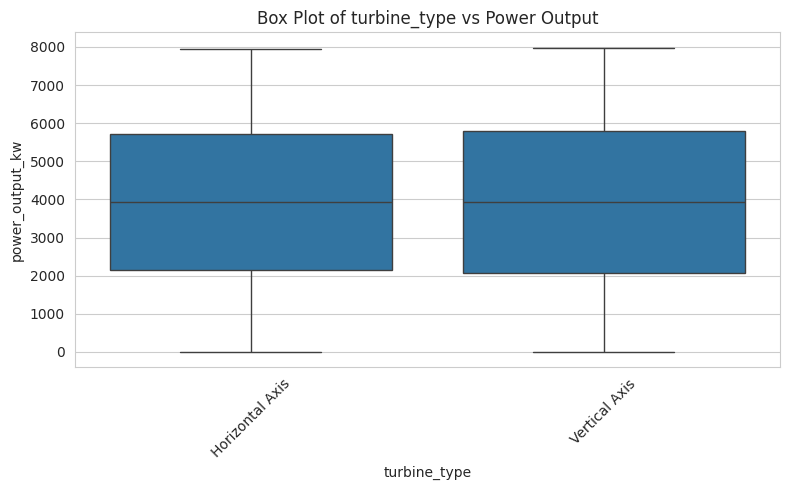

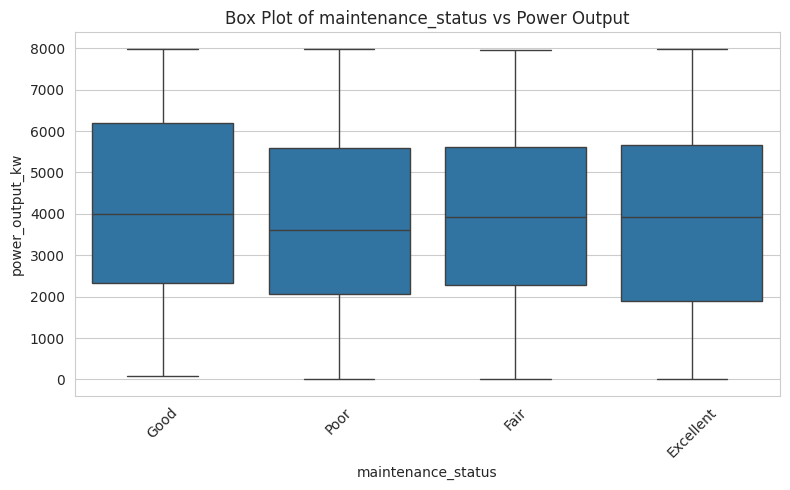

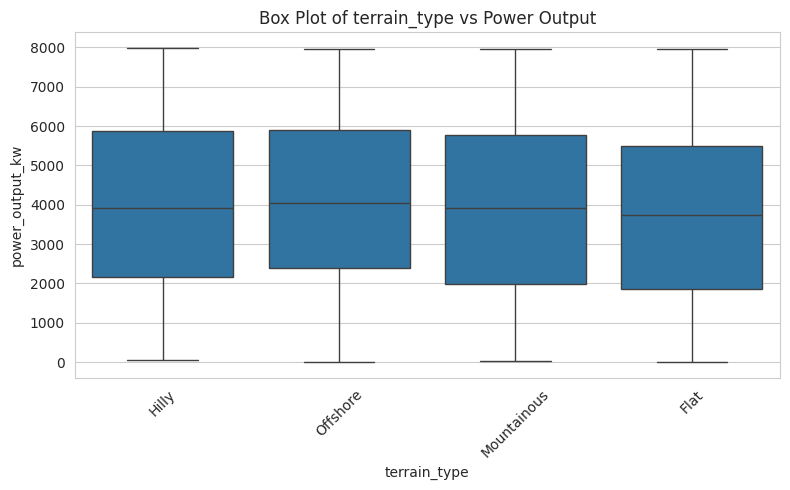

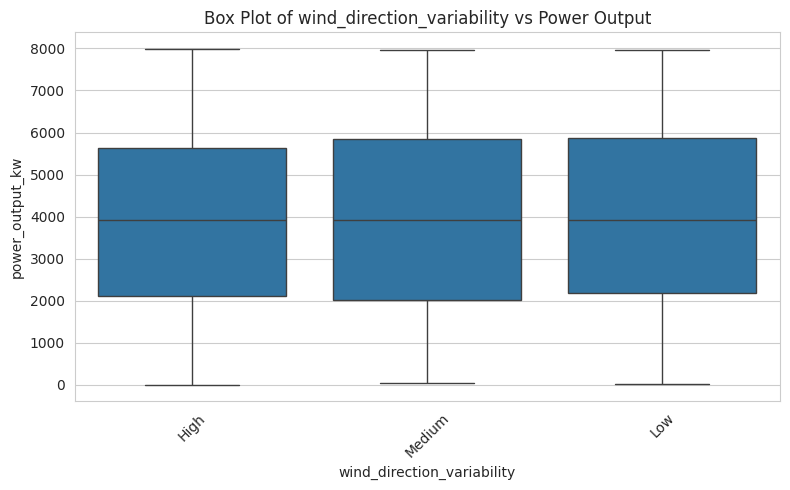

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# List of categorical columns
categorical_cols = [
    'turbine_type',
    'maintenance_status',
    'terrain_type',
    'wind_direction_variability'
]

# Set plot style
sns.set_style("whitegrid")

# Create boxplots
for col in categorical_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=col, y='power_output_kw', data=df)
    plt.title(f'Box Plot of {col} vs Power Output')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


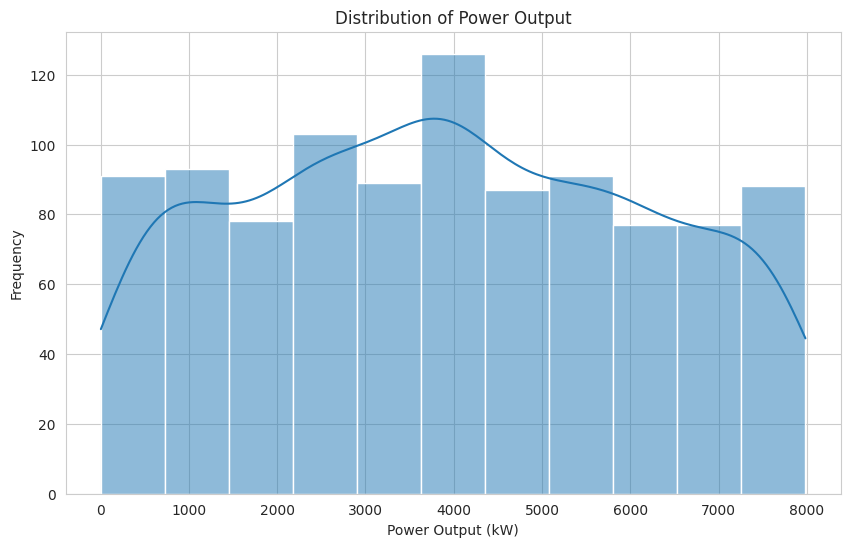

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['power_output_kw'], kde=True)
plt.title('Distribution of Power Output')
plt.xlabel('Power Output (kW)')
plt.ylabel('Frequency')
plt.grid(True)
plt.show()

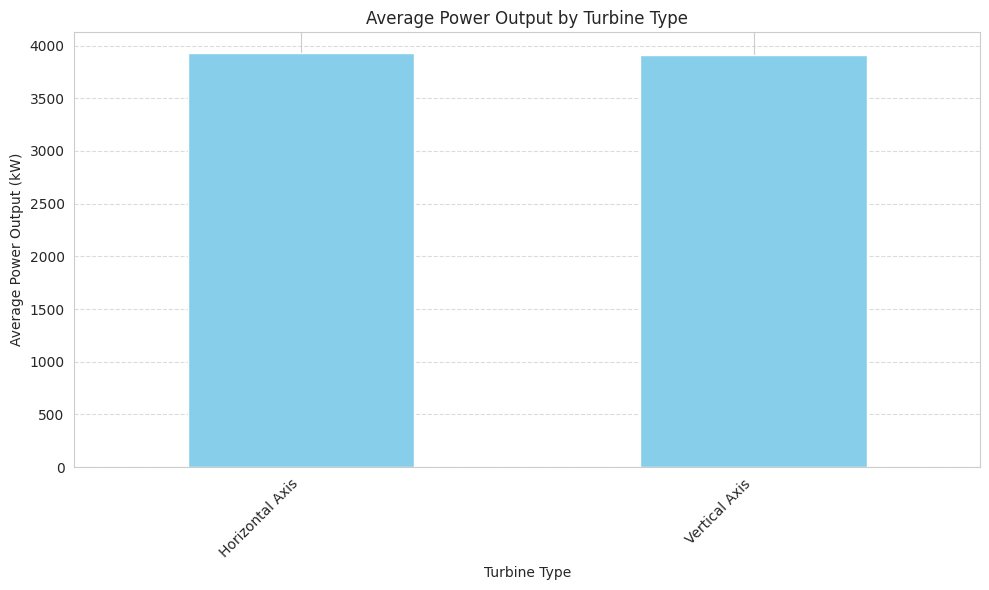

In [ ]:
avg_power_by_turbine_type = df.groupby('turbine_type')['power_output_kw'].mean()

plt.figure(figsize=(10, 6))
avg_power_by_turbine_type.plot(kind='bar', color='skyblue')
plt.title("Average Power Output by Turbine Type")
plt.xlabel("Turbine Type")
plt.ylabel("Average Power Output (kW)")
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

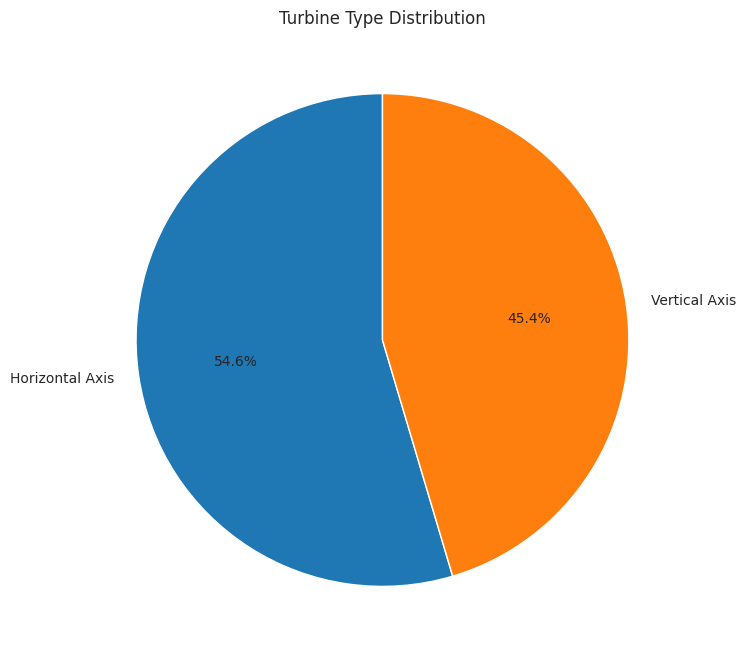

In [ ]:
type_counts = df['turbine_type'].value_counts()

plt.figure(figsize=(8, 8))
type_counts.plot(kind='pie', autopct='%1.1f%%', startangle=90)
plt.title("Turbine Type Distribution")
plt.ylabel("")
plt.show()

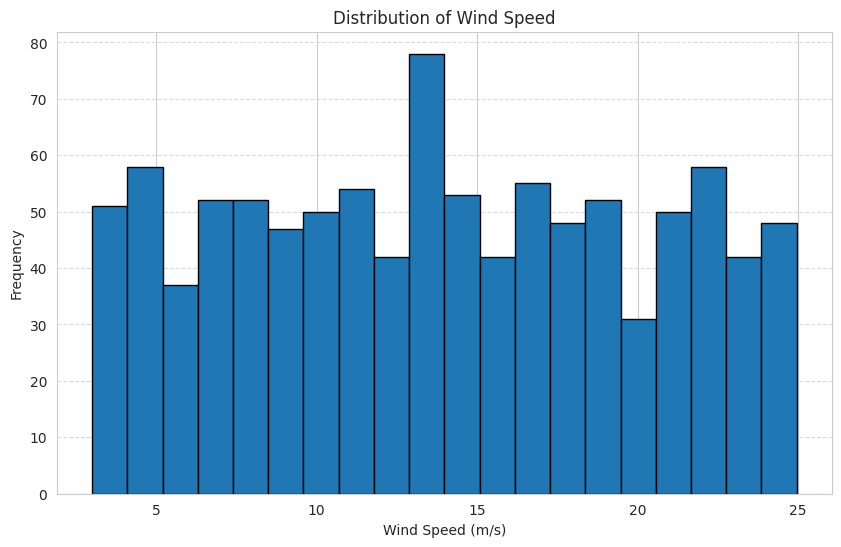

In [ ]:
plt.figure(figsize=(10, 6))
plt.hist(df['wind_speed_ms'], bins=20, edgecolor='black')
plt.title("Distribution of Wind Speed")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

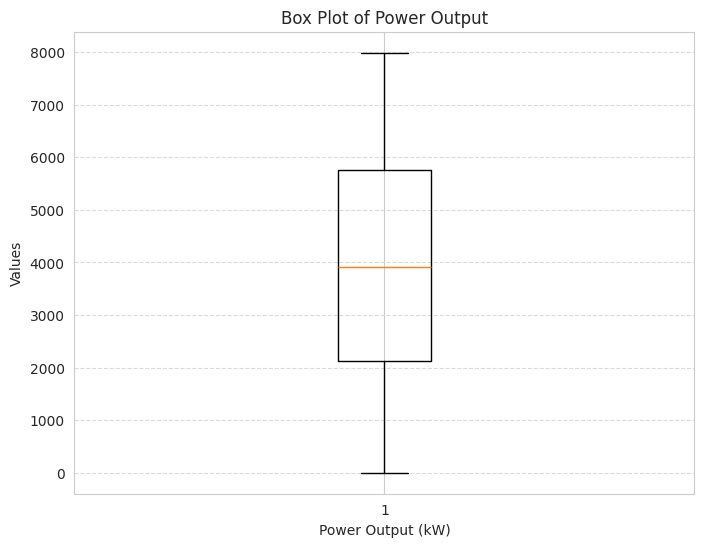

In [ ]:
plt.figure(figsize=(8, 6))
plt.boxplot(df['power_output_kw'])
plt.title("Box Plot of Power Output")
plt.xlabel("Power Output (kW)")
plt.ylabel("Values")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#REGRESSION

***OLS MODEL***

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   wind_speed_ms               1000 non-null   float64
 1   blade_length_m              1000 non-null   float64
 2   turbine_age_years           1000 non-null   float64
 3   hub_height_m                1000 non-null   float64
 4   turbine_type                1000 non-null   object 
 5   rated_power_kw              1000 non-null   float64
 6   cut_in_speed_ms             1000 non-null   float64
 7   cut_out_speed_ms            1000 non-null   float64
 8   air_density_kgm3            1000 non-null   float64
 9   turbulence_intensity        1000 non-null   float64
 10  maintenance_status          1000 non-null   object 
 11  terrain_type                1000 non-null   object 
 12  wind_direction_variability  1000 non-null   object 
 13  power_output_kw             1000 n

In [ ]:
X=df.drop(['turbine_type','maintenance_status','terrain_type','wind_direction_variability','power_output_kw'],axis=1)
Y=df['power_output_kw']

In [ ]:
import statsmodels.api as sm

In [ ]:
X=sm.add_constant(X)
model=sm.OLS(Y,X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        power_output_kw   R-squared:                       0.008
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9338
Date:                Mon, 16 Feb 2026   Prob (F-statistic):              0.495
Time:                        04:49:55   Log-Likelihood:                -9136.4
No. Observations:                1000   AIC:                         1.829e+04
Df Residuals:                     990   BIC:                         1.834e+04
Df Model:                           9                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                 2771.9527 

In [ ]:
print("Accuracy:",model.rsquared*100,"%")

Accuracy: 0.8417216184727461 %


In [ ]:
df3=pd.get_dummies(df)

In [ ]:
df3.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 23 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   wind_speed_ms                      1000 non-null   float64
 1   blade_length_m                     1000 non-null   float64
 2   turbine_age_years                  1000 non-null   float64
 3   hub_height_m                       1000 non-null   float64
 4   rated_power_kw                     1000 non-null   float64
 5   cut_in_speed_ms                    1000 non-null   float64
 6   cut_out_speed_ms                   1000 non-null   float64
 7   air_density_kgm3                   1000 non-null   float64
 8   turbulence_intensity               1000 non-null   float64
 9   power_output_kw                    1000 non-null   float64
 10  turbine_type_Horizontal Axis       1000 non-null   bool   
 11  turbine_type_Vertical Axis         1000 non-null   bool  

In [ ]:
X=df3.drop('power_output_kw',axis=1)
Y=df3['power_output_kw']

In [ ]:
for feature in df3.columns:
  df3[feature]=df3[feature].astype(float)

In [ ]:
import statsmodels.api as sm

X_ols = df3.drop('power_output_kw', axis=1)
Y_ols = df3['power_output_kw']


X_ols = sm.add_constant(X_ols)

model = sm.OLS(Y_ols, X_ols).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:        power_output_kw   R-squared:                       0.017
Model:                            OLS   Adj. R-squared:                 -0.001
Method:                 Least Squares   F-statistic:                    0.9435
Date:                Mon, 16 Feb 2026   Prob (F-statistic):              0.525
Time:                        04:49:55   Log-Likelihood:                -9132.0
No. Observations:                1000   AIC:                         1.830e+04
Df Residuals:                     981   BIC:                         1.840e+04
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
const 

In [ ]:
print("Accuracy:",model.rsquared*100,"%")

Accuracy: 1.7017144999200262 %


#CLASSIFICATION



In [ ]:
df['power_output_kw'].mean()

np.float64(3922.021060717606)

In [ ]:
df4=df3
df4['power_output_kw_']=df['power_output_kw']>3922

In [ ]:
df4['power_output_kw_']=df4['power_output_kw_'].astype(int)
df4['power_output_kw_'].value_counts()

,count
power_output_kw_,
1,509
0,491


In [ ]:
X=df4.drop('power_output_kw_',axis=1)
Y=df4['power_output_kw_']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
for feature in df3.columns:
  df3[feature]=df3[feature].astype(float)

In [ ]:
from sklearn.linear_model import LogisticRegression

classification_model = LogisticRegression(max_iter=1000)
classification_model.fit(X_train_scaled, y_train)

y_pred = classification_model.predict(X_test_scaled)


In [ ]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)


[[97  1]
 [ 3 99]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98        98
           1       0.99      0.97      0.98       102

    accuracy                           0.98       200
   macro avg       0.98      0.98      0.98       200
weighted avg       0.98      0.98      0.98       200



In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy*100,"%")

Accuracy: 98.0 %


#Classification Using Neural Network

In [ ]:
import pandas as pd
import numpy as np


df4 = df3.copy()

mean_value = df4['power_output_kw'].mean()

df4['power_output_kw_'] = (df4['power_output_kw'] > mean_value).astype(int)


X = df4.drop(['power_output_kw_', 'power_output_kw'], axis=1)
Y = df4['power_output_kw_']


for col in X.columns:
    X[col] = X[col].astype(float)


from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42,
    stratify=Y
)


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()#hidden


model.add(Dense(32, activation='relu', input_shape=(X_train_scaled.shape[1],)))


model.add(Dense(16, activation='relu'))


model.add(Dense(1, activation='sigmoid'))


model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)


model.fit(
    X_train_scaled,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)



y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int)


from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy * 100, "%")

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.5738 - loss: 0.6831 - val_accuracy: 0.5625 - val_loss: 0.6903
Epoch 2/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5368 - loss: 0.6923 - val_accuracy: 0.5437 - val_loss: 0.6885
Epoch 3/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5900 - loss: 0.6684 - val_accuracy: 0.5375 - val_loss: 0.6883
Epoch 4/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6164 - loss: 0.6711 - val_accuracy: 0.5375 - val_loss: 0.6895
Epoch 5/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6102 - loss: 0.6694 - val_accuracy: 0.5188 - val_loss: 0.6909
Epoch 6/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6720 - loss: 0.6511 - val_accuracy: 0.5125 - val_loss: 0.6917
Epoch 7/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6088 - loss: 0.6545 - val_accuracy: 0.5437 - val_loss: 0.6938
Epoch 8/50
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6805 - loss: 0.6399 - val_accuracy: 0.5375 - val_loss: 0.6944
Ep

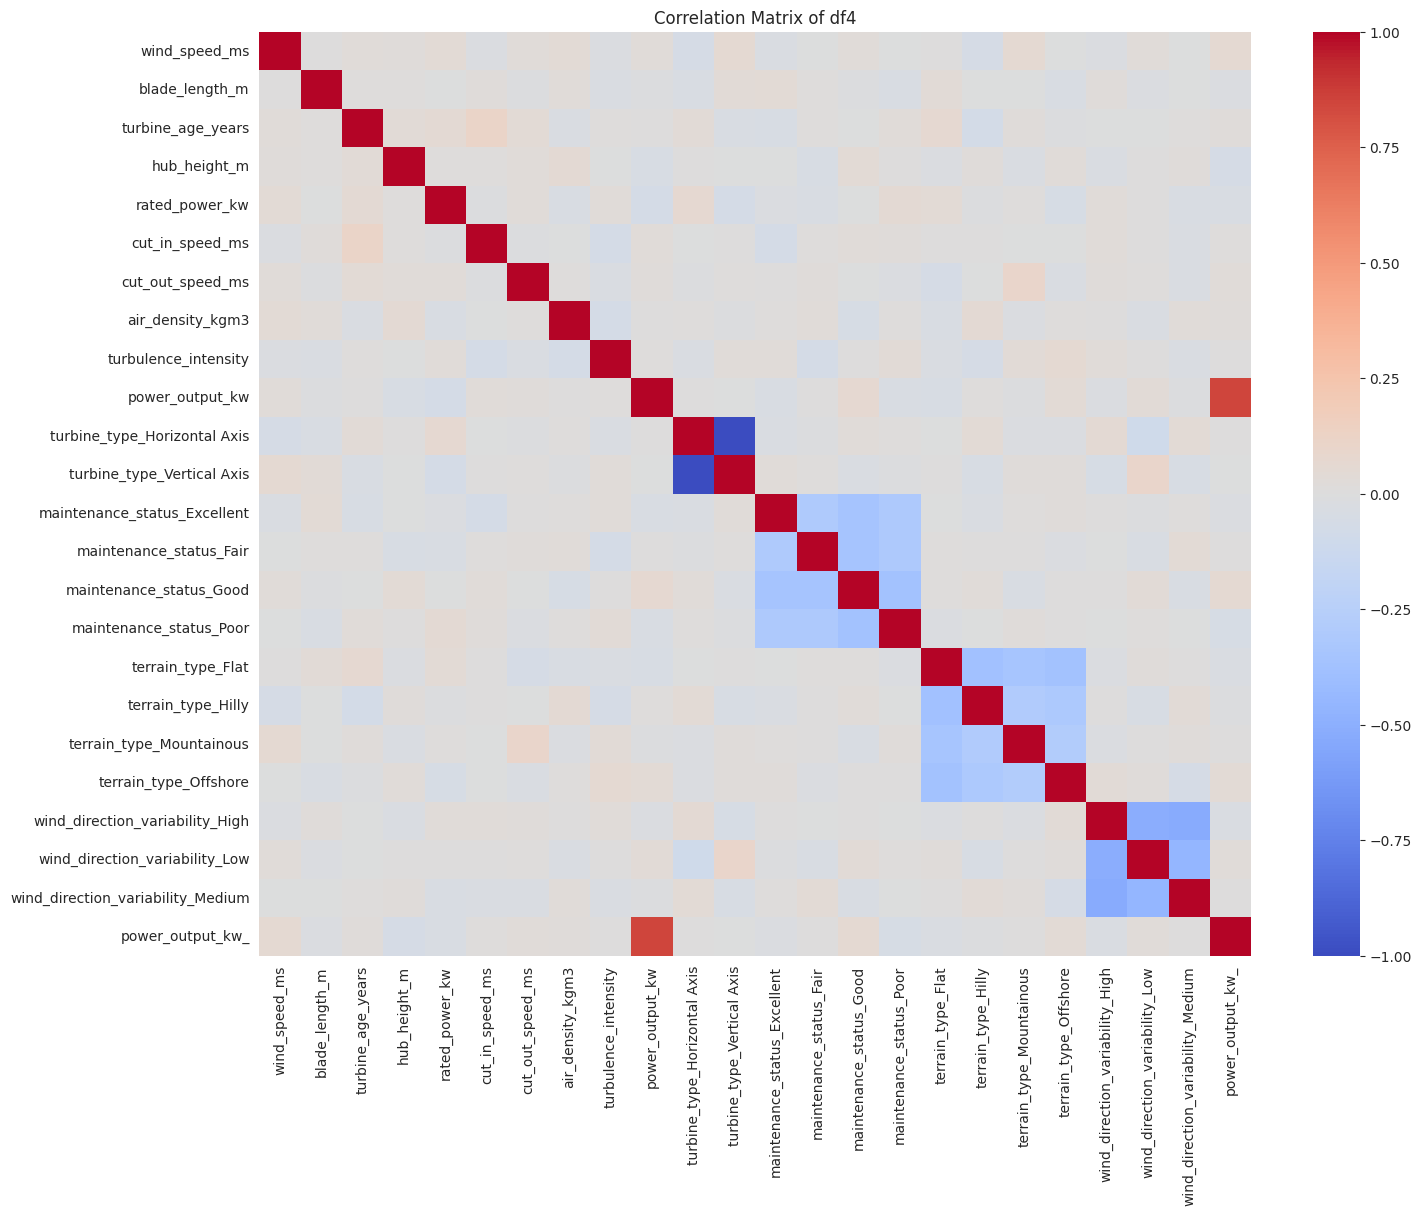

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

correlation_matrix = df4.corr()

plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of df4')
plt.show()

#UI Interface For User



In [ ]:
!pip install gradio

In [ ]:
import joblib

In [ ]:
X=df3.drop(['power_output_kw','power_output_kw_'],axis=1)
y=df3['power_output_kw_']

In [ ]:
X.columns

Index(['wind_speed_ms', 'blade_length_m', 'turbine_age_years', 'hub_height_m',
       'rated_power_kw', 'cut_in_speed_ms', 'cut_out_speed_ms',
       'air_density_kgm3', 'turbulence_intensity',
       'turbine_type_Horizontal Axis', 'turbine_type_Vertical Axis',
       'maintenance_status_Excellent', 'maintenance_status_Fair',
       'maintenance_status_Good', 'maintenance_status_Poor',
       'terrain_type_Flat', 'terrain_type_Hilly', 'terrain_type_Mountainous',
       'terrain_type_Offshore', 'wind_direction_variability_High',
       'wind_direction_variability_Low', 'wind_direction_variability_Medium'],
      dtype='object')

In [ ]:
import joblib

In [ ]:
from sklearn.ensemble import RandomForestRegressor

top_features = df3.drop(['power_output_kw','power_output_kw_'],axis=1).columns
X_reg = df3[top_features]
y_reg = df3['power_output_kw']
model_reg=RandomForestRegressor(random_state=42)
model_reg.fit(X_reg,y_reg)
joblib.dump(model_reg, 'regression_model.pkl')
joblib.dump(top_features, 'regression_features.pkl')

['regression_features.pkl']

In [ ]:
import gradio as gr
import joblib
import numpy as np

model = joblib.load("regression_model.pkl")
features = joblib.load("regression_features.pkl")

def predict_power(*inputs):
    data = np.array(inputs).reshape(1, -1)
    prediction = model.predict(data)
    return float(prediction[0])

inputs = [gr.Number(label=feature) for feature in features]

app = gr.Interface(
    fn=predict_power,
    inputs=inputs,
    outputs=gr.Number(label="Predicted Power Output (kW)"),
    title="Power Output Prediction App",
    description="Enter feature values to predict power_output_kw"
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9f98fc53102e237645.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


#Output Screen:
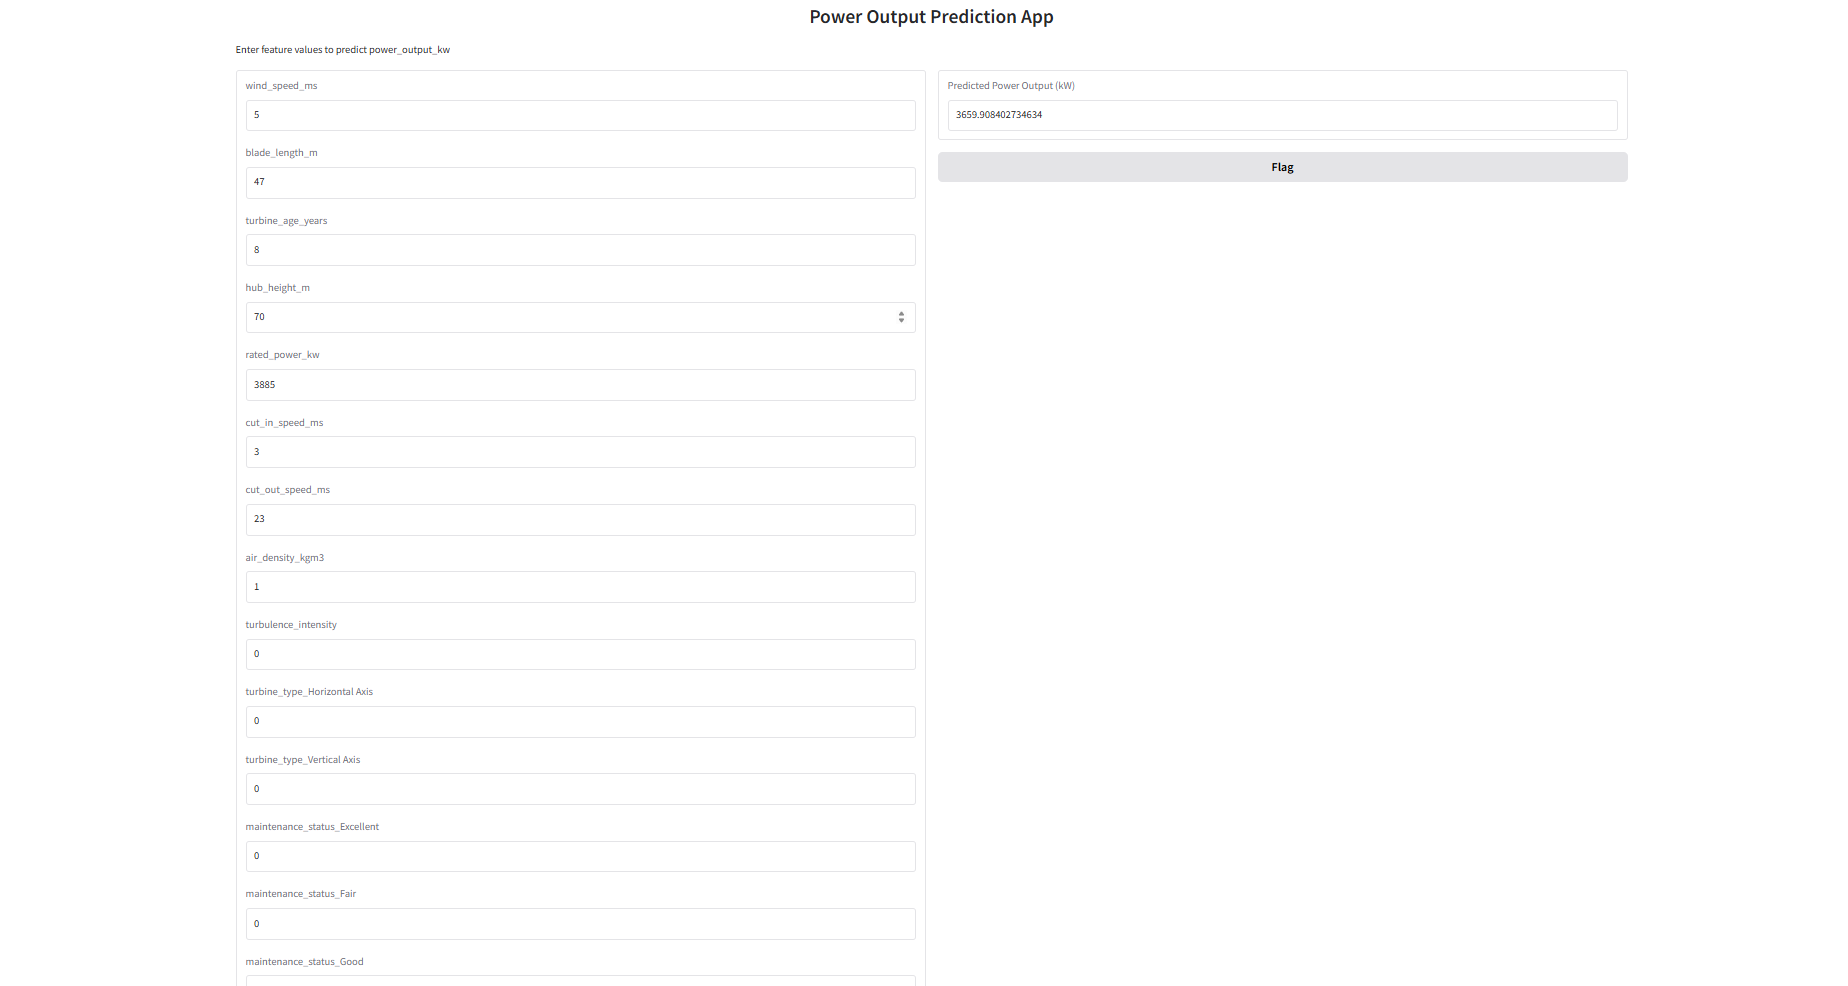

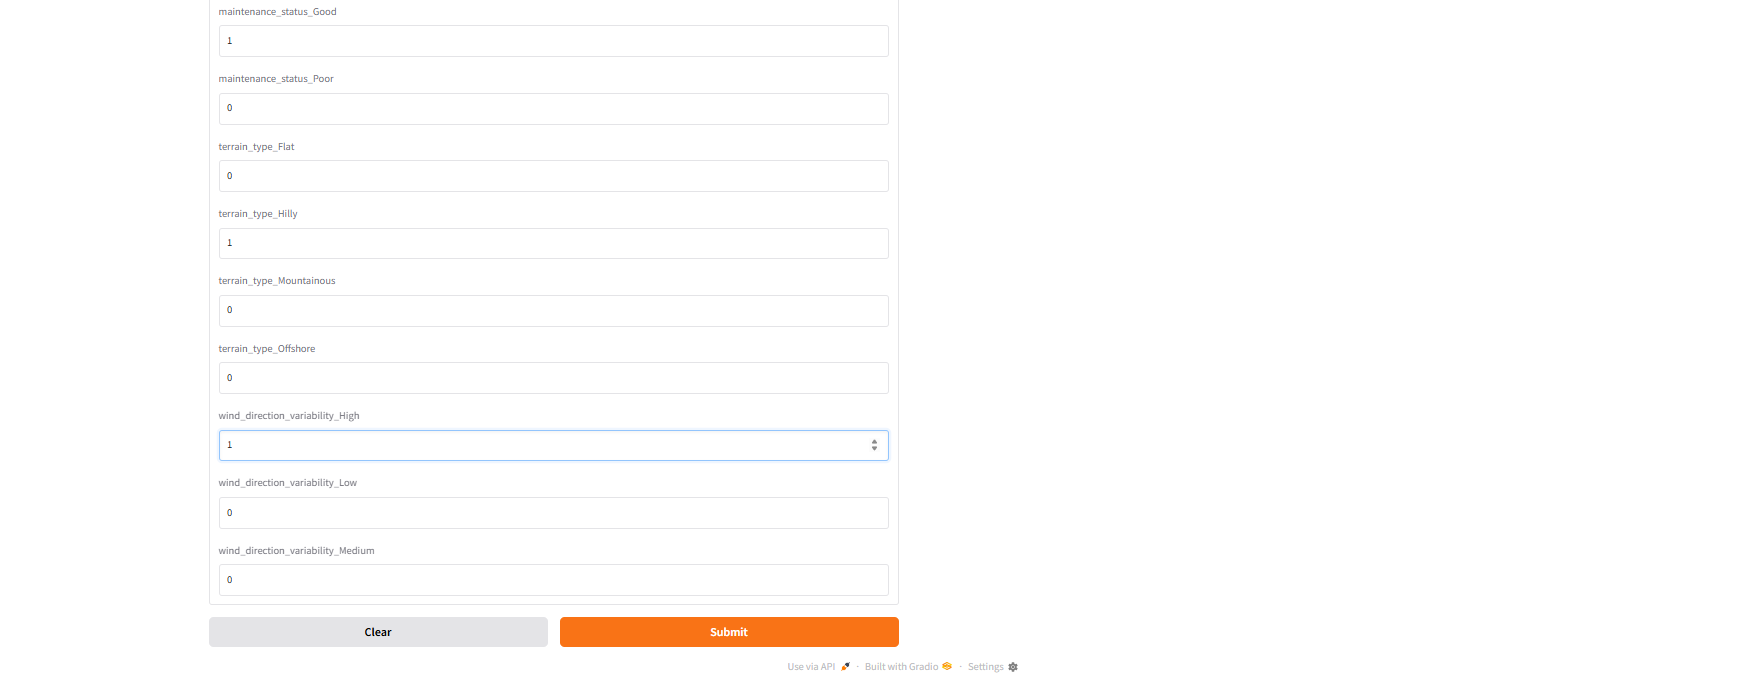